<p align="center">
  <span style="color:Navy; font-size:200%; font-weight:bold; vertical-align:middle;">
     Mapas en python con Cartopy
  </span>
</p>
<p align="center" style="line-height:1.2;">
  <span style="color:RoyalBlue; font-size:160%;">Tema : Uso de librería Cartopy en Python</span><br/>
  <span style="font-size:100%;color:forestgreen"> Curso Dinámica del Clima  |  Semestre 2027-I</span>
</p>

---


Cartopy es la biblioteca estándar de Python para la visualización de datos geoespaciales e integración con Matplotlib.

Permite definir diferentes tipos de proyecciones (ortográfica, cilíndrica, cónica, etc.) de manera sencilla.

Incluye elementos naturales y culturales predeterminados como líneas de costa, fronteras, ríos, tierra, lagos y océanos


### **<font color="SlateBlue"> Proyecciones principales </font>**

|Proyección     | Tipo |Aplicación                           |
|---------|---------|-------------------------------------|
|`ccrs.PlateCarree()`   | Equirrectangular| Define una proyección cartográfica. Coloca directamente longitud en X y latitud en Y.  |  
|`ccrs.Mercator()`  | Mercator | Navegación marítima/aérea y mapas regionales. Preserva ángulos locales pero distorsiona áreas polares.|
|`ccrs.Orthographic()`| Orográfica  | Mapas globales para publicaciones científicas; ofrece un equilibrio estético entre distorsión de área y forma.   |
|`ccrs.Robinson()`|Robinson| Mapas globales para publicaciones científicas; ofrece un equilibrio estético entre distorsión de área y forma.|
|`ccrs.NorthPolarStereo()`    |  | |

### **<font color="SlateBlue"> Comandos principales </font>**

| Comando |Aplicación                           |
|---------|---------|
|`import cartopy.crs as ccrs`   | Módulo del Coordinate Reference System (CRS). Define tanto la proyección visual del mapa como el sistema de coordenadas de los datos de entrada |
|`import cartopy.feature as cfeature`  | Módulo para agregar capas geográficas prediseñadas (líneas de costa, fronteras, ríos, océanos). | 
|`fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Nombre()})`| : Inicializa un eje de Matplotlib configurado con una proyección cartográfica específica.  | 
|`ax.add_feature()`| Incorpora elementos visuales al lienzo (ej. cfeature.COASTLINE, cfeature.BORDERS.with_scale('50m')).| 


Para trabajar con cartopy en colab hay que descargar las dependencias de esta librería con:
```python
pip install xarray netCDF4 matplotlib cartopy

In [14]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import xarray as xr

import numpy as np

# **<font color = "coral"> Proyecciones Geográficas </font>**

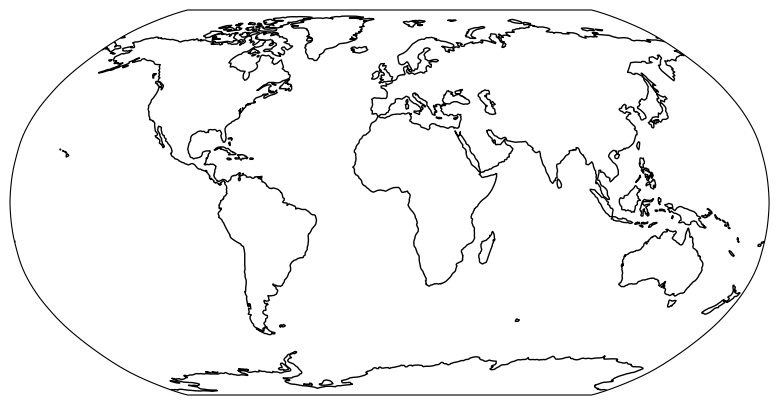

In [6]:
fig = plt.figure(figsize=(10,5))
ax = plt.axes(projection = ccrs.Robinson())

ax.add_feature(cfeature.COASTLINE) # Mostrar las fronteras geograficas
plt.show()

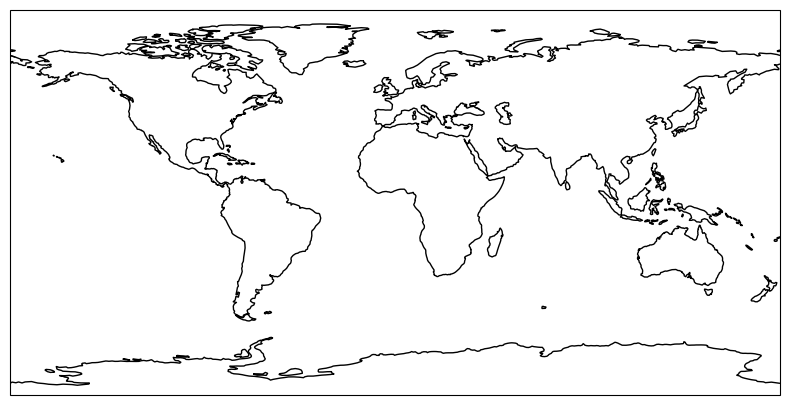

In [ ]:
fig = plt.figure(figsize=(10,5)) #Lienzo 
ax = plt.axes(projection = ccrs.PlateCarree()) # Lo que vamos a dibujar en ese lienzo

ax.add_feature(cfeature.COASTLINE) # Mostrar las fronteras geograficas
plt.show()

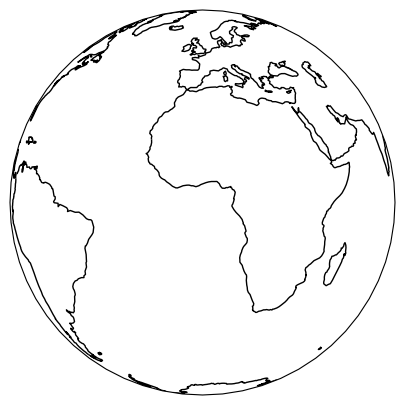

In [8]:
fig = plt.figure(figsize=(10,5)) #Lienzo 
ax = plt.axes(projection = ccrs.Orthographic()) # Lo que vamos a dibujar en ese lienzo

ax.add_feature(cfeature.COASTLINE) # Mostrar las fronteras geograficas
plt.show()

# **<font color = "coral"> Acceso a datos netCDF en malla </font>**

# **<font color = "coral"> EVAPORACIÓN </font>**

In [50]:
ds = xr.open_dataset("era5_evaporation_monthly_climatology_1deg.nc")
print(ds)

<xarray.Dataset> Size: 93MB
Dimensions:     (valid_time: 360, lat: 180, lon: 360)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 1991-01-01T06:00:00 ... 2020-...
  * lat         (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon         (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
Data variables:
    e           (valid_time, lat, lon) float32 93MB ...
Attributes:
    CDI:                       Climate Data Interface version 2.1.1 (https://...
    Conventions:               CF-1.7
    institution:               European Centre for Medium-Range Weather Forec...
    GRIB_centre:               ecmf
    GRIB_centreDescription:    European Centre for Medium-Range Weather Forec...
    history:                   Mon Aug 31 12:36:06 2026: cdo -P 4 remapcon,r3...
    CDO:                       Climate Data Operators version 2.1.1 (https://...
    cdo_openmp_thread_number:  4


In [ ]:
ds.dims #dimensiones del archivo

FrozenMappingWarningOnValuesAccess({'valid_time': 360, 'lat': 180, 'lon': 360})

In [38]:
ds.coords #cordenadas de la variable de evaporación e = e(time, lat, lon)

Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 1991-01-01T06:00:00 ... 2020-...
  * lat         (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon         (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0

In [51]:
# Guardar la variable de evaporacion

eva = ds["e"]

In [39]:
print(eva.attrs)

{'standard_name': 'lwe_thickness_of_water_evaporation_amount', 'long_name': 'Evaporation', 'units': 'm of water equivalent', 'GRIB_dataType': 'fc', 'GRIB_typeOfLevel': 'surface', 'GRIB_stepType': 'avgad', 'GRIB_gridType': 'regular_ll', 'GRIB_cfName': 'lwe_thickness_of_water_evaporation_amount', 'GRIB_cfVarName': 'e', 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid', 'GRIB_iDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_jDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_latitudeOfFirstGridPointInDegrees': np.float64(90.0), 'GRIB_latitudeOfLastGridPointInDegrees': np.float64(-90.0), 'GRIB_longitudeOfFirstGridPointInDegrees': np.float64(0.0), 'GRIB_longitudeOfLastGridPointInDegrees': np.float64(359.75), 'GRIB_missingValue': np.float64(3.4028234663852886e+38), 'GRIB_name': 'Evaporation', 'GRIB_shortName': 'e', 'GRIB_units': 'm of water equivalent', 'GRIB_surface': np.float64(0.0)}


In [ ]:
# ERA5 usa la siguiente convencion: signo positivo = evaporacion, signo negativo = condensacion

eva_mm_day = np.abs(eva) * 1000 # para tener unidades de mm/day

In [16]:
eva_mm_day[0]

<xarray.DataArray 'e' (lat: 180, lon: 360)> Size: 259kB
array([[0.0101924 , 0.0101924 , 0.0101924 , ..., 0.01018542, 0.0101924 ,
        0.0101924 ],
       [0.00814259, 0.00823293, 0.00825357, ..., 0.00814708, 0.00814429,
        0.00812986],
       [0.00371775, 0.00391807, 0.00413841, ..., 0.00406897, 0.00393662,
        0.00380818],
       ...,
       [0.4041783 , 0.396368  , 0.38871512, ..., 0.421865  , 0.4163201 ,
        0.4105301 ],
       [0.37137458, 0.36871365, 0.36587963, ..., 0.37648955, 0.3749035 ,
        0.37322277],
       [0.2660683 , 0.26460057, 0.26317987, ..., 0.2702169 , 0.26889396,
        0.2675198 ]], shape=(180, 360), dtype=float32)
Coordinates:
  * lat         (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon         (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
    valid_time  datetime64[ns] 8B 1991-01-01T06:00:00
Attributes: (12/21)
    standard_name:                            lwe_thickness_of_water_evaporat...
    long_name:                                Evaporation
    units:                                    m of water equivalent
    GRIB_dataType:                            fc
    GRIB_typeOfLevel:                         surface
    GRIB_stepType:                            avgad
    ...                                       ...
    GRIB_longitudeOfLastGridPointInDegrees:   359.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Evaporation
    GRIB_shortName:                           e
    GRIB_units:                               m of water equivalent
    GRIB_surface:                             0.0

In [17]:
eva_mm_day[0,0]

<xarray.DataArray 'e' (lon: 360)> Size: 1kB
array([0.0101924 , 0.0101924 , 0.0101924 , 0.0101924 , 0.0101924 ,
       0.0101924 , 0.0101924 , 0.0101924 , 0.0101924 , 0.0101924 ,
       0.0101924 , 0.0101924 , 0.01022733, 0.01024828, 0.01024828,
       0.01024828, 0.01024828, 0.01024828, 0.01024828, 0.01027063,
       0.01036377, 0.01039729, 0.01039729, 0.01044619, 0.01047925,
       0.01049415, 0.01059473, 0.01063199, 0.01065061, 0.01069671,
       0.0107512 , 0.01080707, 0.0108108 , 0.01085923, 0.01102361,
       0.01104177, 0.01104177, 0.01115027, 0.01125178, 0.01129369,
       0.01138309, 0.01154049, 0.01158938, 0.01170533, 0.01173979,
       0.01185993, 0.01192698, 0.01207506, 0.01211091, 0.01223245,
       0.01230974, 0.01238658, 0.01246341, 0.01258914, 0.01267482,
       0.01261754, 0.01267854, 0.01275537, 0.01280427, 0.01281125,
       0.01283779, 0.01280753, 0.01280054, 0.01274187, 0.01257283,
       0.01247924, 0.01238703, 0.01227109, 0.0121244 , 0.01201823,
       0.01192836, 0.01176678, 0.01164664, 0.0115563 , 0.01138214,
       0.01126293, 0.01109623, 0.01094349, 0.01080659, 0.01067667,
       0.01054396, 0.01050904, 0.01050205, 0.010401  , 0.01035863,
       0.01031672, 0.0102818 , 0.01015467, 0.01009786, 0.01002988,
       0.00999495, 0.00999495, 0.00999495, 0.00999495, 0.01005083,
       0.01008436, 0.01008436, 0.01008436, 0.01008436, 0.01008436,
...
       0.00925363, 0.00925363, 0.00923267, 0.00919775, 0.00911952,
       0.00910834, 0.00910834, 0.00910834, 0.00910834, 0.00912697,
       0.00913815, 0.00913815, 0.00913815, 0.00913815, 0.0091307 ,
       0.00907854, 0.00907854, 0.00907854, 0.00906736, 0.00904874,
       0.00904874, 0.00904874, 0.00904874, 0.00904874, 0.00906969,
       0.00910462, 0.00910462, 0.00907854, 0.00907481, 0.00907481,
       0.00907481, 0.00907481, 0.00907481, 0.00907481, 0.00910974,
       0.00913069, 0.00914187, 0.0092201 , 0.0092201 , 0.00926899,
       0.00930951, 0.00937656, 0.00946178, 0.00951067, 0.00953675,
       0.00957773, 0.0096825 , 0.00976399, 0.00977517, 0.00981009,
       0.00988692, 0.00993163, 0.01000986, 0.01000986, 0.01003594,
       0.01003966, 0.01000474, 0.00998378, 0.00998378, 0.00998378,
       0.01003594, 0.01004339, 0.01004339, 0.0100364 , 0.00999869,
       0.01001731, 0.01001731, 0.01001731, 0.01001033, 0.00996144,
       0.00996144, 0.00996144, 0.00996144, 0.00995399, 0.00990183,
       0.00990928, 0.01001732, 0.01005084, 0.01005084, 0.01003222,
       0.01002104, 0.01002104, 0.01002104, 0.01002104, 0.01002104,
       0.01005596, 0.01007692, 0.01007692, 0.01007692, 0.01008437,
       0.01013653, 0.01013653, 0.01018542, 0.0101924 , 0.0101924 ],
      dtype=float32)
Coordinates:
  * lon         (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
    valid_time  datetime64[ns] 8B 1991-01-01T06:00:00
    lat         float64 8B -89.5
Attributes: (12/21)
    standard_name:                            lwe_thickness_of_water_evaporat...
    long_name:                                Evaporation
    units:                                    m of water equivalent
    GRIB_dataType:                            fc
    GRIB_typeOfLevel:                         surface
    GRIB_stepType:                            avgad
    ...                                       ...
    GRIB_longitudeOfLastGridPointInDegrees:   359.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Evaporation
    GRIB_shortName:                           e
    GRIB_units:                               m of water equivalent
    GRIB_surface:                             0.0

In [ ]:
eva_mm_day[0,0,0] # accedemos al valor del tiempo 0 con una lat y log especifica (la inicial)

<xarray.DataArray 'e' ()> Size: 4B
array(0.0101924, dtype=float32)
Coordinates:
    valid_time  datetime64[ns] 8B 1991-01-01T06:00:00
    lon         float64 8B 0.0
    lat         float64 8B -89.5
Attributes: (12/21)
    standard_name:                            lwe_thickness_of_water_evaporat...
    long_name:                                Evaporation
    units:                                    m of water equivalent
    GRIB_dataType:                            fc
    GRIB_typeOfLevel:                         surface
    GRIB_stepType:                            avgad
    ...                                       ...
    GRIB_longitudeOfLastGridPointInDegrees:   359.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Evaporation
    GRIB_shortName:                           e
    GRIB_units:                               m of water equivalent
    GRIB_surface:                             0.0

# **<font color = "coral"> Calculando la climatologia de evaporacion </font>**

In [52]:
# calculando la climatologia de la evaporacion

climatologia = eva_mm_day.mean( dim = "valid_time")

In [22]:
climatologia[0,0] # fijamos una coordenada geografica

<xarray.DataArray 'e' ()> Size: 4B
array(0.00963645, dtype=float32)
Coordinates:
    lon      float64 8B 0.0
    lat      float64 8B -89.5
Attributes: (12/21)
    standard_name:                            lwe_thickness_of_water_evaporat...
    long_name:                                Evaporation
    units:                                    m of water equivalent
    GRIB_dataType:                            fc
    GRIB_typeOfLevel:                         surface
    GRIB_stepType:                            avgad
    ...                                       ...
    GRIB_longitudeOfLastGridPointInDegrees:   359.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                Evaporation
    GRIB_shortName:                           e
    GRIB_units:                               m of water equivalent
    GRIB_surface:                             0.0

In [54]:
# climatologia es un arreglo multidimensional, guardamos cada coordenada (lat, lon) y el valor de la climatologia e evaporacion de cada nodo de la malla

lon = climatologia.lon.values
lat = climatologia.lat.values
datos = climatologia.values

In [26]:
lon[0]
datos[0]

array([0.00963645, 0.00965305, 0.00967169, 0.00968967, 0.009706  ,
       0.0097246 , 0.0097416 , 0.00975746, 0.00977775, 0.00980112,
       0.00982374, 0.0098453 , 0.0098699 , 0.00988784, 0.00990997,
       0.00993036, 0.00995195, 0.0099793 , 0.01000608, 0.01003215,
       0.01006551, 0.01009865, 0.01013671, 0.01017619, 0.01021592,
       0.01025449, 0.01029561, 0.01034448, 0.01038684, 0.01043284,
       0.01048511, 0.01053503, 0.01058388, 0.01063657, 0.01068751,
       0.01074062, 0.01079823, 0.010858  , 0.01091869, 0.01097596,
       0.01102407, 0.0110793 , 0.01113156, 0.01118805, 0.01123954,
       0.01128534, 0.01133426, 0.01137925, 0.01142847, 0.01147227,
       0.01151171, 0.01153953, 0.01157134, 0.01160124, 0.011624  ,
       0.01164197, 0.01166024, 0.01167944, 0.01169198, 0.01169647,
       0.01169542, 0.01166477, 0.01163713, 0.01159957, 0.01154826,
       0.01150201, 0.011456  , 0.01140269, 0.01135697, 0.01131242,
       0.01126179, 0.01119594, 0.01111963, 0.01102926, 0.01093

# **<font color = "Coral">  Gráfica de la climatología global de evaporación </font>**

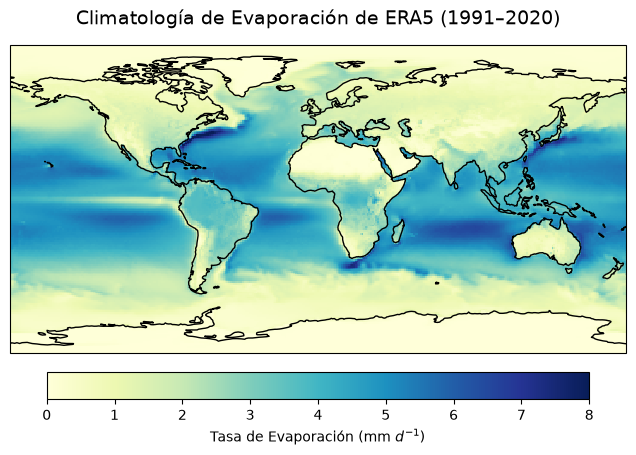

In [58]:
fig = plt.figure(figsize=(10,5)) #Lienzo 
ax = plt.axes(projection = ccrs.PlateCarree()) # Lo que vamos a dibujar en ese lienzo

ax.coastlines()

im = ax.pcolormesh(
    lon,
    lat,
    datos,
    transform = ccrs.PlateCarree(),
    cmap= "YlGnBu",
    vmin = 0,
    vmax = 8
)

cbar = plt.colorbar(im, 
                    label='Tasa de Evaporación (mm $d^{-1}$)', 
                    orientation='horizontal', 
                    pad=0.05, 
                    shrink=0.7) 

ax.set_global() # para visualizar todo el mapa

# ax.add_feature(cfeature.COASTLINE) # Mostrar las fronteras geograficas

plt.title('Climatología de Evaporación de ERA5 (1991–2020)', fontsize=14, pad=15)

plt.show()

lon: 0.0 359.0
lat: -89.5 89.5
data: 0.0054681976 9.120471


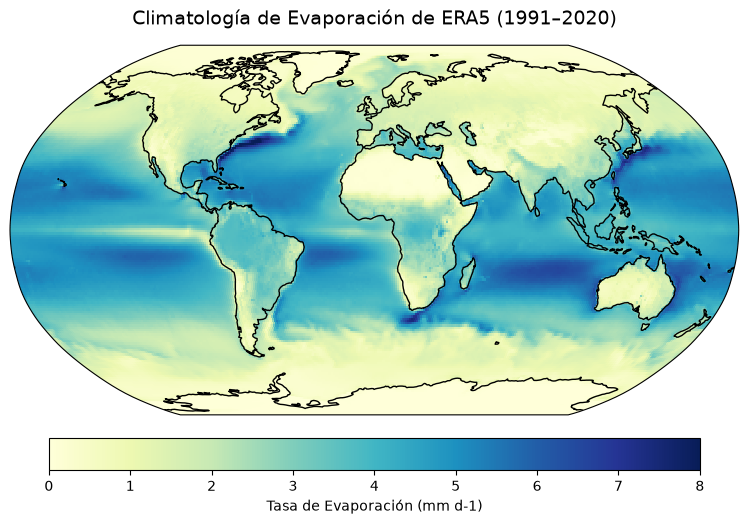

In [65]:
fig = plt.figure(figsize=(12, 6))

ax = plt.axes(projection=ccrs.Robinson())

ax.coastlines()

lon = climatologia.lon.values
lat = climatologia.lat.values
data = climatologia.values

print("lon:", lon.min(), lon.max())
print("lat:", lat.min(), lat.max())
print("data:", data.min(), data.max())

im = ax.pcolormesh(
    lon,
    lat,
    data,
    transform=ccrs.PlateCarree(),
    cmap="YlGnBu",
    vmin=0,
    vmax=8
)

cbar = plt.colorbar(im, 
                    label='Tasa de Evaporación (mm d-1)', 
                    orientation='horizontal', 
                    pad=0.05, 
                    shrink=0.7)

ax.set_global()

plt.title('Climatología de Evaporación de ERA5 (1991–2020)', fontsize=14, pad=15)
plt.show()

# **<font color = "coral"> PRECIPITACIÓN </font>**

In [59]:
ds = xr.open_dataset("era5_precipitation_monthly_climatology_1deg.nc")
print(ds)

<xarray.Dataset> Size: 93MB
Dimensions:     (valid_time: 360, lat: 180, lon: 360)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 1991-01-01T06:00:00 ... 2020-...
  * lat         (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon         (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
Data variables:
    tp          (valid_time, lat, lon) float32 93MB ...
Attributes:
    CDI:                       Climate Data Interface version 2.1.1 (https://...
    Conventions:               CF-1.7
    institution:               European Centre for Medium-Range Weather Forec...
    GRIB_centre:               ecmf
    GRIB_centreDescription:    European Centre for Medium-Range Weather Forec...
    history:                   Mon Aug 31 12:47:31 2026: cdo -P 4 remapcon,r3...
    CDO:                       Climate Data Operators version 2.1.1 (https://...
    cdo_openmp_thread_number:  4


In [71]:
# La precipitación total en ERA5 está definida por 'tp' en m/day
tp = ds['tp'] * 1000.0

# Calculamos la media climatológica para 1991-2020
climatologia_tp = tp.mean(dim='valid_time')

# **<font color = "Coral">  Gráfica de la climatología global de precipitación </font>**

In [72]:
lon = climatologia_tp.lon.values
lat = climatologia_tp.lat.values
datos = climatologia_tp.values

lon: 0.0 359.0
lat: -89.5 89.5
data: 0.0022939045 41.300026


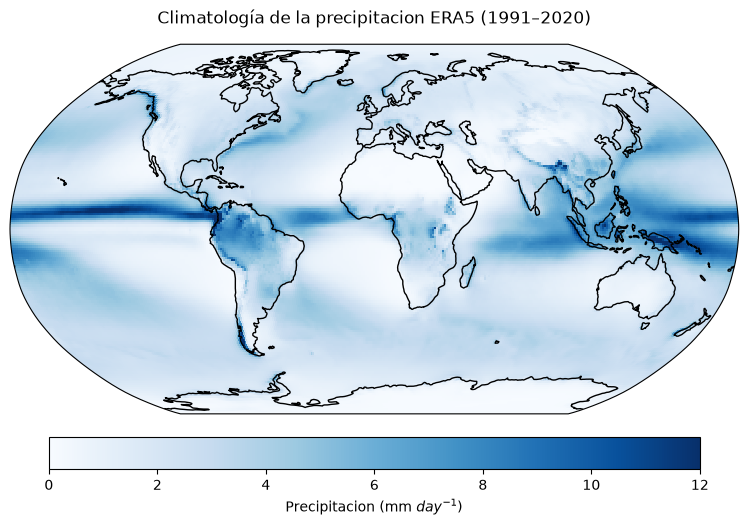

In [75]:
fig = plt.figure(figsize=(12, 6))

ax = plt.axes(projection=ccrs.Robinson())

ax.coastlines()

lon = climatologia_tp.lon.values
lat = climatologia_tp.lat.values
data = climatologia_tp.values

print("lon:", lon.min(), lon.max())
print("lat:", lat.min(), lat.max())
print("data:", data.min(), data.max())

im = ax.pcolormesh(
    lon,
    lat,
    data,
    transform=ccrs.PlateCarree(),
    cmap="Blues",
    vmin=0,
    vmax=12
)

cbar = plt.colorbar(im, 
                    label='Precipitacion (mm $day^{-1}$)', 
                    orientation='horizontal', 
                    pad=0.05, 
                    shrink=0.7)

plt.title('Climatología de la precipitacion ERA5 (1991–2020)', 
          fontsize=12, pad=15)

ax.set_global()

plt.show()

# **<font color = "Coral">  Calculamos E-P </font>**

Obtener la climatologia global de E-P y graficarla 

# **<font color = "Coral">  Gráfica de la climatología global de E-P</font>**

## Flujos de humedad

Para poder ver los flujos de humedad integrados necesitamos lo siguiente:
$$
\mathbf Q=\frac{1}{g}\int_0^{p_s} q\mathbf v\,dp
$$
dónde: 

$q$: humedad específica $[\mathrm{kg\,kg^{-1}}]\\$ 
$\mathbf {v}(u,v)$: viento horizontal $[\mathrm{m\,s^{-1}}]\\$
$p:\,$ presión $[\mathrm{Pa}]\\$
$g$: gravedad $[\mathrm{m\,s^{-2}}]\\$

A partir de ERA5 podemos obtener:

$$
Q_u = \frac{1}{g}\int_0^{p_s} q\cdot u \\
\space \\
Q_v = \frac{1}{g}\int_0^{p_s} q\cdot v \\
$$

Para entonces poder calcular los flujos y generar una gráfica con $E - P$ en contornos y Los flujos integrados sobrepuestos.


In [ ]:
ivt_filename = "era5_ivt_monthly_climatology_1deg.nc" 
ds_vectors = xr.open_dataset(ivt_filename)

# Calculamos la climatología de los flujos (kg / m / s)
Qu = ds_vectors['viwve'].mean(dim='valid_time')
Qv = ds_vectors['viwvn'].mean(dim='valid_time')
ds_vectors.close()